In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import skimage.io as io 
import skimage.exposure as exp
# import os 
# os.chdir('../../')
# import my_modules.histogramop as hope
# import my_modules.my_lib as lib
path = 'C:\\Users\\rocco\\Documents\\università\\ESM\\laboratorio\\Immagini\\'

## Trasformata di Fourier 2D

In numpy la trasformata di fourier si calcola con np.fft.fft2, che valuta la DFT su un numero di punti pari proprio alla dimensione dell'immagine. Possiamo usare le funzioni np.abs() e np.angle() per valutare il modulo e la fase della trasformata. 
Per visualizzare meglio la trasformata, eseguiamo un'operazione di shift per vedere le basse frequenze al centro e le alte frequenze ai margini con il comando fft.fftshift(X). Dato che i coefficienti presentano una dinamica estremamente alta, usiamo il logaritmo per migliorare la visualizzazione. Il comando np.fft.fft2 consente anche di specificare il numero di punti su cui calcolare la DFT, e se superiori alle dimensioni dell’immagine, realizza automaticamente lo zero-padding: X = np.fft.fft2(x,(P,Q)).

In [ ]:
# trasformata di Fourier 2D

im = path + 'rettangolo.jpg'

x = np.float32(io.imread(im))
X = np.fft.fft2(x)

Y = np.log(1+np.abs(np.fft.fftshift(X)))

plt.figure(1)
plt.imshow(x, clim=None, cmap='gray')
plt.colorbar()
plt.title("input")
plt.figure(2)
plt.imshow(np.abs(X), clim=None, cmap='gray', extent=(-0.5,0.5,0.5,-0.5))
plt.title("FFT2 X")
plt.figure(3)
plt.imshow(Y, clim=None, cmap='gray', extent=(-0.5,0.5,0.5,-0.5))
plt.title("FFT2 Y")

In [ ]:
# visualizzazione tridimensionale trasformata di fourier 2D

from mpl_toolkits.mplot3d import Axes3D

im = path + 'rettangolo.jpg'
x = np.float32(io.imread(im))

# calcolo trasformata
X = np.fft.fft2(x)
Y = np.log(1+(np.abs(np.fft.fftshift(X)))) 

# creazione assi
m = np.fft.fftshift(np.fft.fftfreq(Y.shape[0]))
n = np.fft.fftshift(np.fft.fftfreq(Y.shape[1]))

# creazione figura
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d') # 111 significa che il sottografico occupa tutto lo spazio disponibile

l,k = np.meshgrid(n,m)
ax.plot_surface(l,k,Y, linewidth=0, cmap='jet')
plt.show()

## DFT e filtraggio lineare

Il prodotto nel dominio della frequenza equivale alla convoluzione nel dominio spaziale, dunque l'analisi frequenziale dei segnali e dei sistemi nel dominio frequenziale è di fondamentale importanza.
Tuttavia se si realizza il prodotto delle DFT dell’immagine di ingresso, X(k,l), e della risposta impulsiva H(k,l) si ottiene la convoluzione circolare delle immagini, che in generale non è uguale alla convoluzione lineare, operazione a cui siamo interessati per realizzare il filtraggio nel discreto. Tuttavia, si può dimostrare, che realizzando opportunamente uno zero padding dell’immagine di partenza la convoluzione circolare coincide con quella lineare. Quindi pur di effettuare il riempimento con zeri, la DFT può essere usata per realizzare il filtraggio lineare.

Nel caso monodimensionale, consideriamo i segnali x di lunghezza L e h risposta impulsiva di lunghezza M. I passi da eseguire sono:
1. Scegliere N >= L+M-1
2. Calcolare la DFT delle due sequenze su N punti -> X(K) e H(K)
3. Calcolare il prodotto Y=X*H
4. Determinare la sequenza filtrata y come IDFT(Y)

Nel caso bidimensionale, consideriamo un'immagine x(m,n) di dimensioni M,N e un kernel H(m,n) di dimensioni A,B. I passi da eseguire sono:
1. Scegliere P >= M+A-1, Q >= N+B-1
2. Calcolare la DFT2 delle due immagini su P,Q punti.
3. Calcolare il prodotto Y=X*H
4. Determinare l'immagine filtrata con IDFT(Y)

Osserviamo che in generale l'antitrasformata di fourier avrà dimensioni pari a (P,Q). Per determinare un output più piccolo, passare a IDFT la tupla (M,N).

In [ ]:
# filtraggio lineare - caso monodimensionale

'''
Proviamo allora a determinare attraverso la DFT e la IDFT la risposta del filtro con x = [1,2,3,4] e h = [1,1,1]. In questo caso bisogna calcolare la DFT almeno su N = 4 + 3 −1 = 6 punti per garantire la correttezza del risultato.
'''

x = np.array([1,2,3,4], dtype=np.float32)
h = np.array([1,1,1], dtype=np.float32)
X = np.fft.fft(x, 6)
H = np.fft.fft(h, 6)
Y1 = H*X
y1 = np.real(np.fft.ifft(Y1,6))
y2 = np.convolve(x,h)

print(f'y1 - {y1}')
print(f'y2 - {y2}')

M,N = (512, 512)
A,B = (3, 3)
MSE=5782.30078125


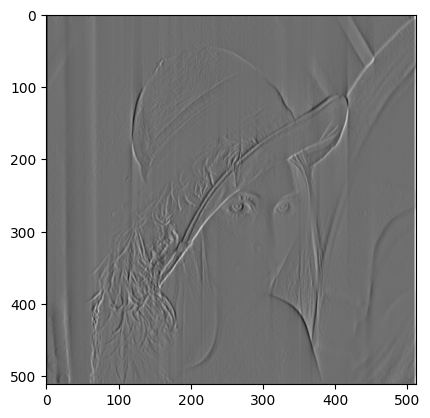

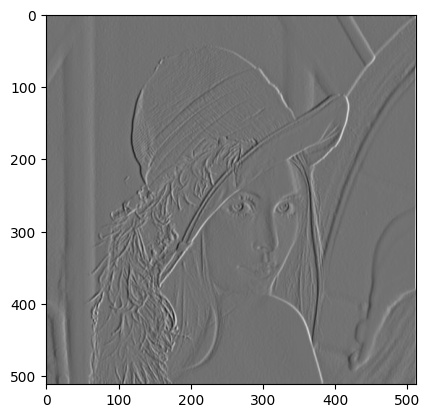

In [ ]:
# filtraggio lineare - Caso bidimensionale

def mse(x1,x2):
    return np.mean((x1-x2)**2)

x = np.float32(io.imread(path+'lena.jpg'))
h = np.array([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=np.float32)

M,N = x.shape
A,B = h.shape

print(f'M,N = {M,N}')
print(f'A,B = {A,B}')

P = M+A-1
Q = N+B-1

X = np.fft.fft2(x, (P,Q))
H = np.fft.fft2(np.rot90(h,2), (P,Q))

A = A//2
B = B//2

Y1 = X*H
y1 = np.real(np.fft.ifft2(Y1))[A:(A+M), B:(B+N)]
# y1 = np.real(np.fft.ifft2(Y1, x.shape))
y2 = ndi.correlate(x,h, mode='constant')

print(f'MSE={mse(y1,y2)}')
plt.close('all')
plt.figure(1)
plt.imshow(y1, clim=None, cmap='gray')
plt.figure(2)
plt.imshow(y2, clim=None, cmap='gray')
plt.show()



In [ ]:
# progetto di filtri nel dominio della frequenza - Ringing

lena = path+'lena.jpg'
x = np.float32(io.imread(lena))
X = np.fft.fftshift(np.fft.fft2(x))

M,N = x.shape
m = np.fft.fftshift(np.fft.fftfreq(M))
n = np.fft.fftshift(np.fft.fftfreq(N))

l,k = np.meshgrid(m,n)
D = np.sqrt(l**2 + k**2)
D0 = 0.1
H = (D<=D0)
Y = X*H

y = np.real(np.fft.ifft2(np.fft.fftshift(Y)))

plt.figure()
plt.imshow(H, clim=[0,1], cmap='gray', extent=(-0.5,0.5,0.5,-0.5))
plt.title('Funzione di trasferimento')
plt.figure()
plt.imshow(np.log(1+np.abs(X)), clim=None, cmap='jet')
plt.title('LENA_FFT2')
plt.figure()
plt.imshow(np.log(1+np.abs(Y)), clim=None, cmap='jet')
plt.title('Y')
plt.figure()
plt.subplot(1,2,1)
plt.imshow(x, clim=[0,255], cmap='gray')
plt.subplot(1,2,2)
plt.imshow(y, clim=None, cmap='gray')
plt.show()

In [ ]:
# Filtri gaussiani 

def gaussLP(x,sigma:float):
    M,N = x.shape
    m = np.fft.fftshift(np.fft.fftfreq(M))
    n = np.fft.fftshift(np.fft.fftfreq(N))
    l,k = np.meshgrid(n,m)
    D = (l**2 + k **2)**0.5
    H = np.exp(-(D**2)/2*(sigma**2))
    X = np.fft.fftshift(np.fft.fft2(x))
    Y = X*H
    y = np.real(np.fft.ifft2(np.fft.fftshift(Y)))
    return y

testo = path+'testo.tif'
x = np.float32(io.imread(testo))
y = gaussLP(x, 10)

plt.figure(1)
plt.imshow(x, clim=[0,255], cmap='gray')
plt.figure(2)
plt.imshow(y, clim=[0,255], cmap='gray')

In [ ]:
# Filtraggio Rumore Periodico - MSE 46!

im = path+'lenarumorosa.y'
x = np.fromfile(im, dtype=np.int16)
x = x.reshape((512,512))
x = np.float32(x)
X = np.fft.fft2(x)
z = np.float32(io.imread(path+'lena.jpg'))

''' 
Nell'immagine di lena con rumore, c'è una sinusoide sommata. Non abbiamo una delta ma una sinc, perchè non è una vera sinusoide ma una sinusoide troncata (moltiplicata per rect). 
Per rimuoverla, possiamo creare dei filtri circolari
'''

# definizione filtro 

M,N = x.shape
m = np.fft.fftshift(np.fft.fftfreq(M))
n = np.fft.fftshift(np.fft.fftfreq(N))

l,k = np.meshgrid(n,m)
nu = 0.2
mu = 0.2
B = 0.05
D1 = ((k+mu)**2 + (l-nu)**2)**0.5
D2 = ((k-mu)**2 + (l+nu)**2)**0.5
H = (D1>B) & (D2>B)

Y = np.fft.fftshift(X)*H
y = np.real(np.fft.ifft2(np.fft.fftshift(Y)))
print(f"MSE: {np.mean((z-y)**2)}")

plt.figure(1)
plt.imshow(x, clim=[0,255], cmap='gray')
plt.title('input')
plt.figure(2)
plt.imshow(np.log(1+np.abs(np.fft.fftshift(X))), clim=None, cmap='jet', extent=(-0.5,0.5,0.5,-0.5))
plt.title('FFT input')
plt.figure(3)
plt.imshow(H, clim=[0,1], cmap='gray')
plt.title('Funzione di trasferimento')
plt.figure(4)
plt.imshow(y, clim=[0,255], cmap='gray')
plt.title('output')
plt.colorbar()
plt.show()


In [ ]:
# Filtraggio Rumore Periodico - seconda soluzione - MSE 17!
im = path+'lenarumorosa.y'
x = np.fromfile(im, dtype=np.int16)
x = x.reshape((512,512))
x = np.float32(x)
X = np.fft.fft2(x)
z = np.float32(io.imread(path+'lena.jpg')) # per MSE

# definizione filtro rettangolare
M,N = x.shape
m = np.fft.fftshift(np.fft.fftfreq(M))
n = np.fft.fftshift(np.fft.fftfreq(N))
l,k = np.meshgrid(n,m)
mu = 0.2
nu = 0.2
C1 = ((k+mu)**2 + (l-nu)**2) > 0.005
C2 = ((k-mu)**2 + (l+nu)**2) > 0.005
C = C1 & C2
R = ((np.abs(k+mu)>=0.003) & (np.abs(l-nu)>=0.003)) & ((np.abs(k-mu)>=0.003)&(np.abs(l+nu)>=0.003)) 
H = C & R

Y = np.fft.fftshift(X)*H
y = np.real(np.fft.ifft2(np.fft.fftshift(Y)))
print(f"MSE: {np.mean((z-y)**2)}")

plt.figure(1)
plt.imshow(x, clim=[0,255], cmap='gray')
plt.title('input')
plt.figure(2)
plt.imshow(np.log(1+np.abs(np.fft.fftshift(X))), clim=None, cmap='jet', extent=(-0.5,0.5,0.5,-0.5))
plt.title('FFT input')
plt.figure(3)
plt.imshow(H, clim=[0,1], cmap='gray',  extent=(-0.5,0.5,0.5,-0.5))
plt.title('Funzione di trasferimento')
plt.figure(4)
plt.imshow(y, clim=[0,255], cmap='gray')
plt.title('output')
plt.colorbar()
plt.show()